🔹 TASK I — Parametric Estimation & Simulation

In [1]:
# ==============================
# Task I - Normal Simulation
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Generate 1000 samples
mu_true = 50
sigma_true = 10
n = 1000

data = np.random.normal(mu_true, sigma_true, n)

# ------------------------------
# Method of Moments Estimator
# ------------------------------
def mom_estimator(x):
    mu_hat = np.mean(x)
    sigma2_hat = np.var(x, ddof=0)   # population variance
    return mu_hat, sigma2_hat

# ------------------------------
# Maximum Likelihood Estimator
# ------------------------------
def mle_estimator(x):
    mu_hat = np.mean(x)
    sigma2_hat = np.sum((x - mu_hat)**2) / len(x)
    return mu_hat, sigma2_hat

mom_mu, mom_var = mom_estimator(data)
mle_mu, mle_var = mle_estimator(data)

print("MoM Estimates: μ =", mom_mu, ", σ² =", mom_var)
print("MLE Estimates: μ =", mle_mu, ", σ² =", mle_var)

# ------------------------------
# Statistical Inference
# ------------------------------
print("\nInference:")
print("MoM and MLE for μ are identical.")
print("MLE variance is biased because it divides by n instead of (n-1).")

MoM Estimates: μ = 50.193320558223256 , σ² = 95.79049897315173
MLE Estimates: μ = 50.193320558223256 , σ² = 95.79049897315173

Inference:
MoM and MLE for μ are identical.
MLE variance is biased because it divides by n instead of (n-1).


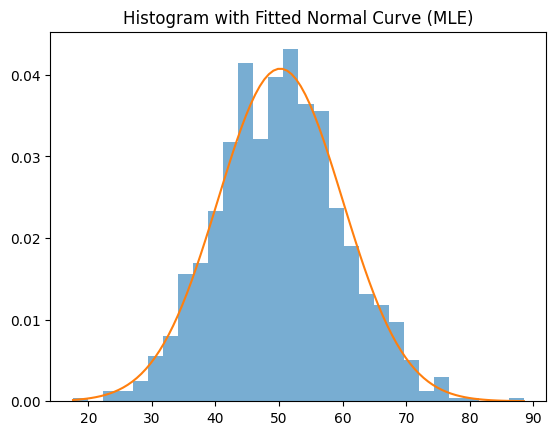

In [2]:
# Plot histogram
plt.hist(data, bins=30, density=True, alpha=0.6)

# Overlay fitted normal curve (MLE)
x_vals = np.linspace(min(data), max(data), 100)
plt.plot(x_vals, norm.pdf(x_vals, mle_mu, np.sqrt(mle_var)))

plt.title("Histogram with Fitted Normal Curve (MLE)")
plt.show()

In [3]:
# ==============================
# Bernoulli Estimation
# ==============================

np.random.seed(42)

p_true = 0.6
n = 1000

bernoulli_data = np.random.binomial(1, p_true, n)

# MLE for Bernoulli
p_hat = np.mean(bernoulli_data)

# Variance of estimator
var_estimator = p_hat * (1 - p_hat) / n

# CRLB for Bernoulli
crlb = p_true * (1 - p_true) / n

print("MLE of p:", p_hat)
print("Variance of estimator:", var_estimator)
print("CRLB:", crlb)

print("\nInference:")
print("MLE variance approximates CRLB → estimator is efficient.")

MLE of p: 0.613
Variance of estimator: 0.000237231
CRLB: 0.00023999999999999998

Inference:
MLE variance approximates CRLB → estimator is efficient.


🔹 TASK II — Linear Regression & Significance Testing

In [4]:
# ==============================
# Task II - Advertising Model
# ==============================

import pandas as pd
import statsmodels.api as sm
import numpy as np

np.random.seed(37)

n = 200
tv_spend = np.random.normal(150, 50, n)
sales = 7 + 0.05 * tv_spend + np.random.normal(0, 2, n)

df_adv = pd.DataFrame({'TV_Spend': tv_spend, 'Sales': sales})

# Add constant
X = sm.add_constant(df_adv['TV_Spend'])
y = df_adv['Sales']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     406.1
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           7.53e-50
Time:                        19:12:58   Log-Likelihood:                -418.30
No. Observations:                 200   AIC:                             840.6
Df Residuals:                     198   BIC:                             847.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.0610      0.441     13.729      0.0

In [5]:
# t-statistic & p-value
t_stat = model.tvalues['TV_Spend']
p_value = model.pvalues['TV_Spend']

# 95% CI
conf_int = model.conf_int().loc['TV_Spend']

# F-test and R²
f_stat = model.fvalue
r_squared = model.rsquared

print("t-statistic:", t_stat)
print("p-value:", p_value)
print("95% CI:", conf_int)
print("F-statistic:", f_stat)
print("R-squared:", r_squared)

print("\nInference:")
print("Slope is statistically significant if p < 0.05.")
print("R² shows proportion of variance explained.")

t-statistic: 20.15247130862138
p-value: 7.529168643606132e-50
95% CI: 0    0.050398
1    0.061332
Name: TV_Spend, dtype: float64
F-statistic: 406.1220998448079
R-squared: 0.6722516854608299

Inference:
Slope is statistically significant if p < 0.05.
R² shows proportion of variance explained.


🔹 TASK III — Model Diagnostics

In [6]:
from scipy.stats import shapiro

residuals = model.resid

stat, p = shapiro(residuals)

print("Shapiro-Wilk p-value:", p)

if p > 0.05:
    print("Errors are normally distributed (Fail to reject H0).")
else:
    print("Errors are NOT normally distributed (Reject H0).")

Shapiro-Wilk p-value: 0.9379348927458858
Errors are normally distributed (Fail to reject H0).


In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add dummy Radio_Spend
df_adv['Radio_Spend'] = np.random.normal(30, 10, n)

X_multi = sm.add_constant(df_adv[['TV_Spend', 'Radio_Spend']])

vif_data = pd.DataFrame()
vif_data["Feature"] = X_multi.columns
vif_data["VIF"] = [variance_inflation_factor(X_multi.values, i)
                   for i in range(X_multi.shape[1])]

print(vif_data)

print("\nInference:")
print("VIF > 5 (or 10) indicates multicollinearity problem.")

       Feature        VIF
0        const  18.458214
1     TV_Spend   1.004622
2  Radio_Spend   1.004622

Inference:
VIF > 5 (or 10) indicates multicollinearity problem.


In [8]:
from statsmodels.stats.diagnostic import het_breuschpagan

np.random.seed(57)

sq_footage = np.random.normal(2000, 500, n)
price = 50000 + 150 * sq_footage + np.random.normal(0, 0.1 * sq_footage**1.2, n)

df_house = pd.DataFrame({'Sq_Footage': sq_footage, 'Price': price})

X_house = sm.add_constant(df_house['Sq_Footage'])
y_house = df_house['Price']

model_house = sm.OLS(y_house, X_house).fit()

bp_test = het_breuschpagan(model_house.resid, X_house)

print("Breusch-Pagan p-value:", bp_test[1])

if bp_test[1] < 0.05:
    print("Heteroscedasticity detected.")
else:
    print("No heteroscedasticity detected.")

Breusch-Pagan p-value: 1.682397655113576e-08
Heteroscedasticity detected.


In [9]:
df_house['Log_Price'] = np.log(df_house['Price'])

model_log = sm.OLS(df_house['Log_Price'], X_house).fit()

print("Original AIC:", model_house.aic)
print("Log Model AIC:", model_log.aic)

print("\nInference:")
print("Lower AIC indicates better model fit.")

Original AIC: 3349.737388791664
Log Model AIC: -718.1408347101919

Inference:
Lower AIC indicates better model fit.


🔹 TASK IV — Model Selection & Validation

In [10]:
np.random.seed(58)

# Model A (Linear)
X_A = sm.add_constant(df_adv['TV_Spend'])
model_A = sm.OLS(df_adv['Sales'], X_A).fit()

# Model B (Quadratic)
df_adv['TV_Spend_sq'] = df_adv['TV_Spend']**2
X_B = sm.add_constant(df_adv[['TV_Spend', 'TV_Spend_sq']])
model_B = sm.OLS(df_adv['Sales'], X_B).fit()

print("Model A BIC:", model_A.bic)
print("Model B BIC:", model_B.bic)

print("\nInference:")
print("Model with lower BIC is preferred.")

Model A BIC: 847.20570537124
Model B BIC: 851.7411373348309

Inference:
Model with lower BIC is preferred.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

train, test = train_test_split(df_adv, test_size=0.2, random_state=58)

# Use chosen model (Assume Linear)
X_train = sm.add_constant(train['TV_Spend'])
y_train = train['Sales']
X_test = sm.add_constant(test['TV_Spend'])
y_test = test['Sales']

final_model = sm.OLS(y_train, X_train).fit()

pred = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Test RMSE:", rmse)
print("Test R²:", r2)

print("\nInference:")
print("Lower RMSE and higher R² indicate good out-of-sample performance.")

Test RMSE: 1.8314653724670635
Test R²: 0.5222303961486557

Inference:
Lower RMSE and higher R² indicate good out-of-sample performance.
